In [9]:
import pandas as pd

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables) 


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [1]:
# Combinar características y etiqueta y guardar como CSV
df = X.copy()
if 'Diagnosis' not in df.columns:
    df['Diagnosis'] = y.squeeze()
df.to_csv('datos\breast_cancer_wisconsin_diagnostic_original.csv', index=False)

# Guardar versión "original" si existe en el objeto descargado
try:
    orig = breast_cancer_wisconsin_diagnostic.data.original
    orig.to_csv('breast_cancer_wisconsin_diagnostic_original.csv', index=False)
except Exception:
    pass

NameError: name 'X' is not defined

## 1. Introducción

1. Problema o pregunta de investigación: 
¿Cuál es la relación entre las características de los tumores y su malignidad en el conjunto de datos de cáncer de mama?

2. Contexto:
El cáncer de mama es una enfermedad muy común entre las mujeres a nivel mundial, por lo que una detección temprana y un diagnóstico adecuado son cruciales para mejorar la tasa de supervivencia a la enfermedad. Este conjunto de datos contiene información sobre diversas características de los tumores, como el tamaño, textura y forma y su clasificación de benignidad o malignidad, por lo que el analizar esta información puede ayudar a identificar patrones y relaciones que pueden ser útiles a la hora de diagnosticar y posteriormente tratar esta afección.

3. Relación entre el problema y la base de datos seleccionada:
Utlizamos el conjunto de datos de [Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) que contiene información sobre 569 casos de cáncer de mama, con 30 características numéricas que describen las propiedades de los tumores, la variable objetivo es la clasificación del tumor como benigno (B) o maligno (M).



## 2. Descripción de la base de datos

Cabe resaltar que en este conjunto de datos cada caso proviene de una imagen en donde se miden muchos núcleos celulares y como no se guarda cada medición de forma individual se resumen cada característica del tumor con tres tipos de valores para representar mejor la información. El primer tipo que en nuestro caso son las variables denotadas con 1, corresponde al promedio de los valores tomados para cada característica en la imagen. Aquellos denotados con 2 corresponden al error estándar, es decir a cuánta variabilidad existe en la característica y el tercer tipo denotado con 3 corresponde al extremo representativo calculado a partir de los valores más altos. En conjunto, estos resúmenes nos permiten visibilizar no solo el nivel general del tumor si no también su heterogeneidad y sus rasgos más extremos.


In [24]:
df = pd.read_csv('breast_cancer_wisconsin_diagnostic_original.csv', delimiter=';')
df.head()

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [25]:
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 569
Número de variables: 32


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  569 non-null    int64  
 1   radius1             569 non-null    float64
 2   texture1            569 non-null    float64
 3   perimeter1          569 non-null    float64
 4   area1               569 non-null    float64
 5   smoothness1         569 non-null    float64
 6   compactness1        569 non-null    float64
 7   concavity1          569 non-null    float64
 8   concave_points1     569 non-null    float64
 9   symmetry1           569 non-null    float64
 10  fractal_dimension1  569 non-null    float64
 11  radius2             569 non-null    float64
 12  texture2            569 non-null    float64
 13  perimeter2          569 non-null    float64
 14  area2               569 non-null    float64
 15  smoothness2         569 non-null    float64
 16  compactness2       

In [26]:
print("\nTipos de datos por variable:")
print(df.dtypes.value_counts())


Tipos de datos por variable:
float64    30
int64       1
str         1
Name: count, dtype: int64


In [32]:
# Clasificación de variables
categoricas = df.select_dtypes(include=['object']).columns.tolist()
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("🔹 Variables categóricas:")
print("\n".join([f"- {col}" for col in categoricas]))

print("\n🔸 Variables numéricas:")
print("\n".join([f"- {col}" for col in numericas]))

🔹 Variables categóricas:
- Diagnosis

🔸 Variables numéricas:
- ID
- radius1
- texture1
- perimeter1
- area1
- smoothness1
- compactness1
- concavity1
- concave_points1
- symmetry1
- fractal_dimension1
- radius2
- texture2
- perimeter2
- area2
- smoothness2
- compactness2
- concavity2
- concave_points2
- symmetry2
- fractal_dimension2
- radius3
- texture3
- perimeter3
- area3
- smoothness3
- compactness3
- concavity3
- concave_points3
- symmetry3
- fractal_dimension3


C:\Users\eduar\AppData\Local\Temp\ipykernel_24980\2670419239.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include=['object']).columns.tolist()


In [29]:
print("\nDescripción de variables numéricas:")
df.describe()


Descripción de variables numéricas:


,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## 3. Analisis inicial de variables

In [31]:
# Conteo de valores únicos por variable
print("\nConteo de valores únicos por variable:")
print(df.nunique().sort_values(ascending=False))


Conteo de valores únicos por variable:
ID                    569
smoothness2           547
fractal_dimension2    545
area3                 544
concave_points1       542
compactness2          541
radius2               540
area1                 539
concavity3            539
compactness1          537
concavity1            537
fractal_dimension3    535
concavity2            533
perimeter2            533
compactness3          529
area2                 528
perimeter1            522
texture2              519
perimeter3            514
texture3              511
concave_points2       507
symmetry3             500
fractal_dimension1    499
symmetry2             498
concave_points3       492
texture1              479
smoothness1           474
radius3               457
radius1               456
symmetry1             432
smoothness3           411
Diagnosis               2
dtype: int64


In [37]:
variables_media = ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1']
df[variables_media].describe()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440


In [38]:
variables_SE = ['radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2']
df[variables_SE].describe()

,radius2,texture2,perimeter2,area2,smoothness2,compactness2,concavity2,concave_points2,symmetry2,fractal_dimension2
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795
std,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646
min,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895
25%,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248
50%,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187
75%,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558
max,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840


In [39]:
variables_worst = ['radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']
df[variables_worst].describe()

,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## 4. Visualizaciones exploratorias basicas

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

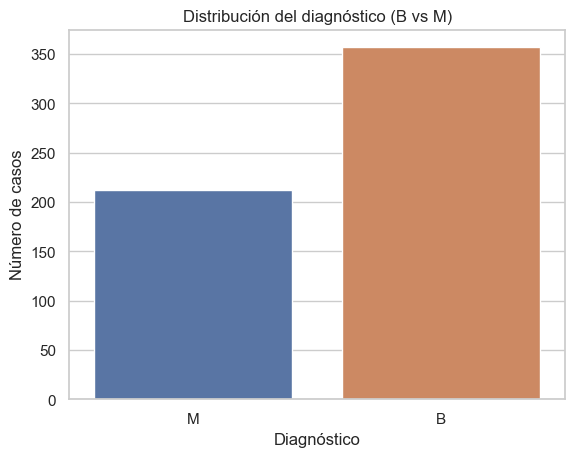

In [49]:
sns.countplot(x="Diagnosis", data=df, hue="Diagnosis", legend=False)
plt.title("Distribución del diagnóstico (B vs M)")
plt.xlabel("Diagnóstico")
plt.ylabel("Número de casos")
plt.show()

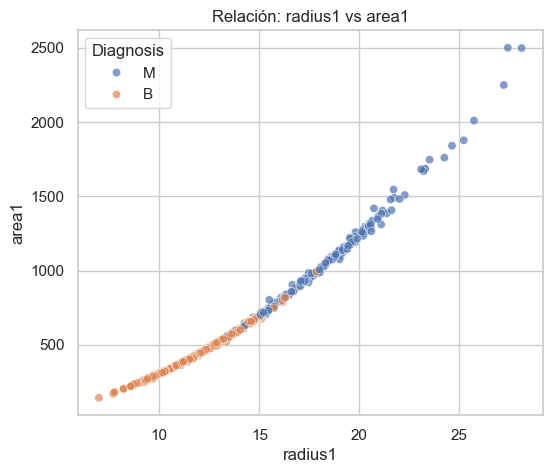

In [62]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="radius1", y="area1", hue="Diagnosis", alpha=0.7)
plt.title("Relación: radius1 vs area1")
plt.xlabel("radius1")
plt.ylabel("area1")
plt.show()

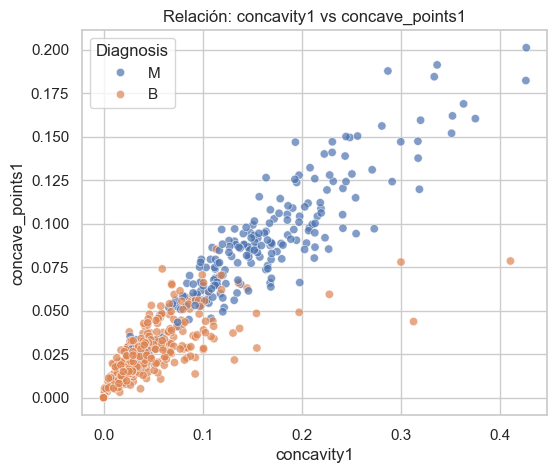

In [56]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="concavity1", y="concave_points1", hue="Diagnosis", alpha=0.7)
plt.title("Relación: concavity1 vs concave_points1")
plt.xlabel("concavity1")
plt.ylabel("concave_points1")
plt.show()

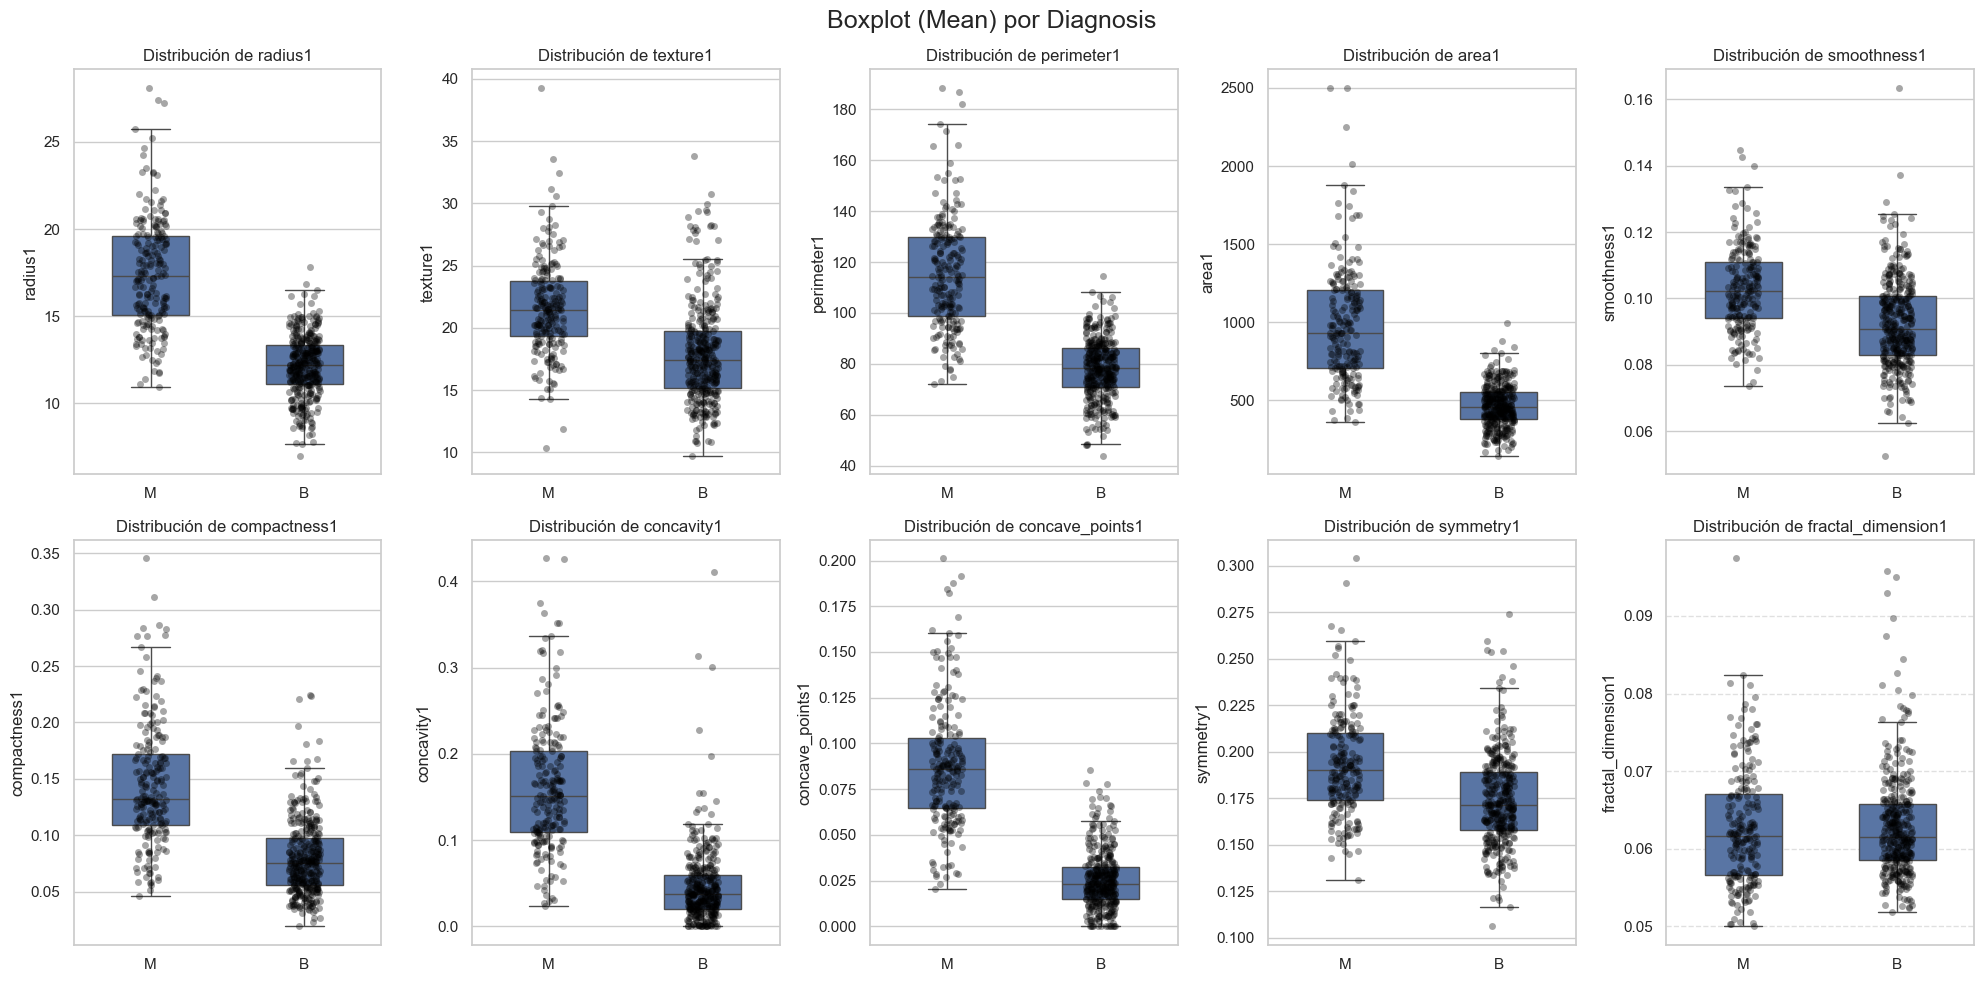

In [108]:
# Filtrar solo las columnas de medias (terminadas en 1) ignorando el ID
mean_features = [col for col in df.columns if col.endswith('1') and col != 'ID']

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(mean_features):
    sns.boxplot(x='Diagnosis', y=col, data=df, ax=axes[i], width=0.5, fliersize=0)
    sns.stripplot(x="Diagnosis", y=col, data=df, ax=axes[i], color="black", alpha=0.35, jitter=True)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('')

fig.suptitle("Boxplot (Mean) por Diagnosis", fontsize=18)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

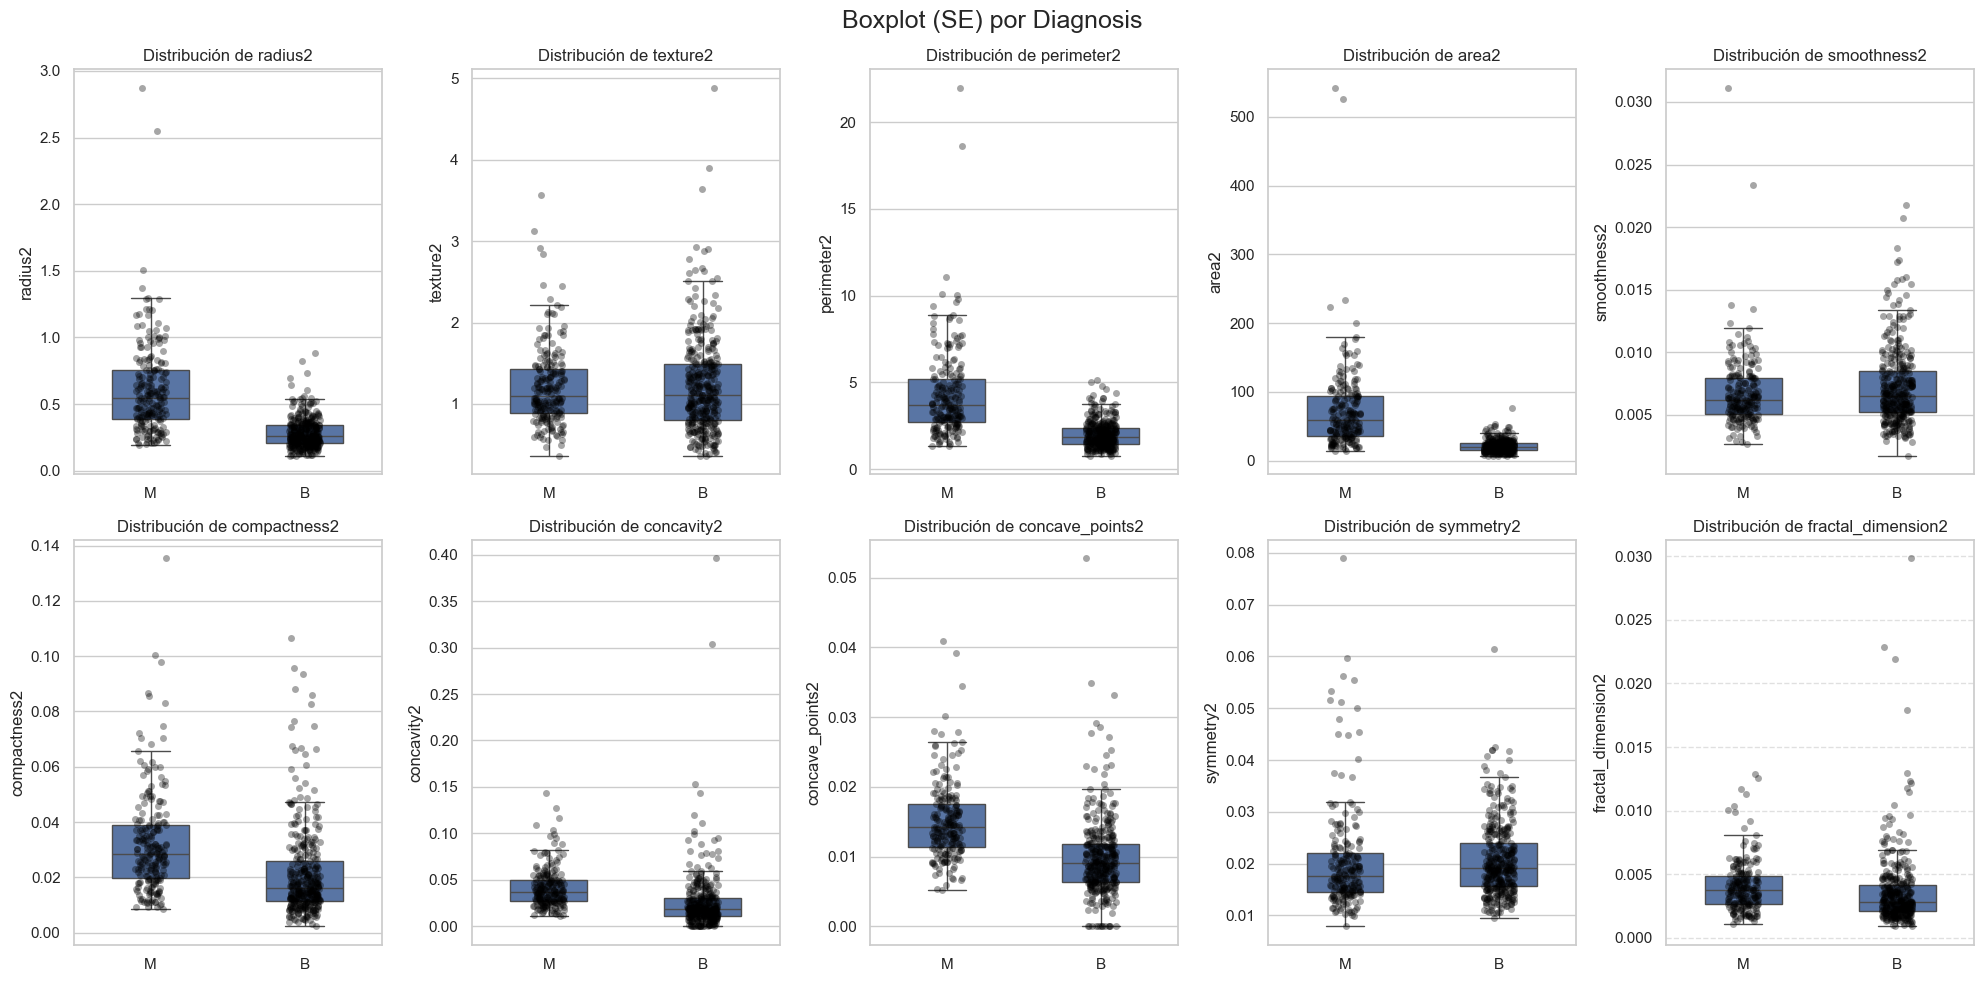

In [107]:
# Filtrar solo las columnas de medias (terminadas en 1) ignorando el ID
mean_features = [col for col in df.columns if col.endswith('2') and col != 'ID']

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(mean_features):
    sns.boxplot(x='Diagnosis', y=col, data=df, ax=axes[i], width=0.5, fliersize=0)
    sns.stripplot(x="Diagnosis", y=col, data=df, ax=axes[i], color="black", alpha=0.35, jitter=True)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('')

fig.suptitle("Boxplot (SE) por Diagnosis", fontsize=18)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

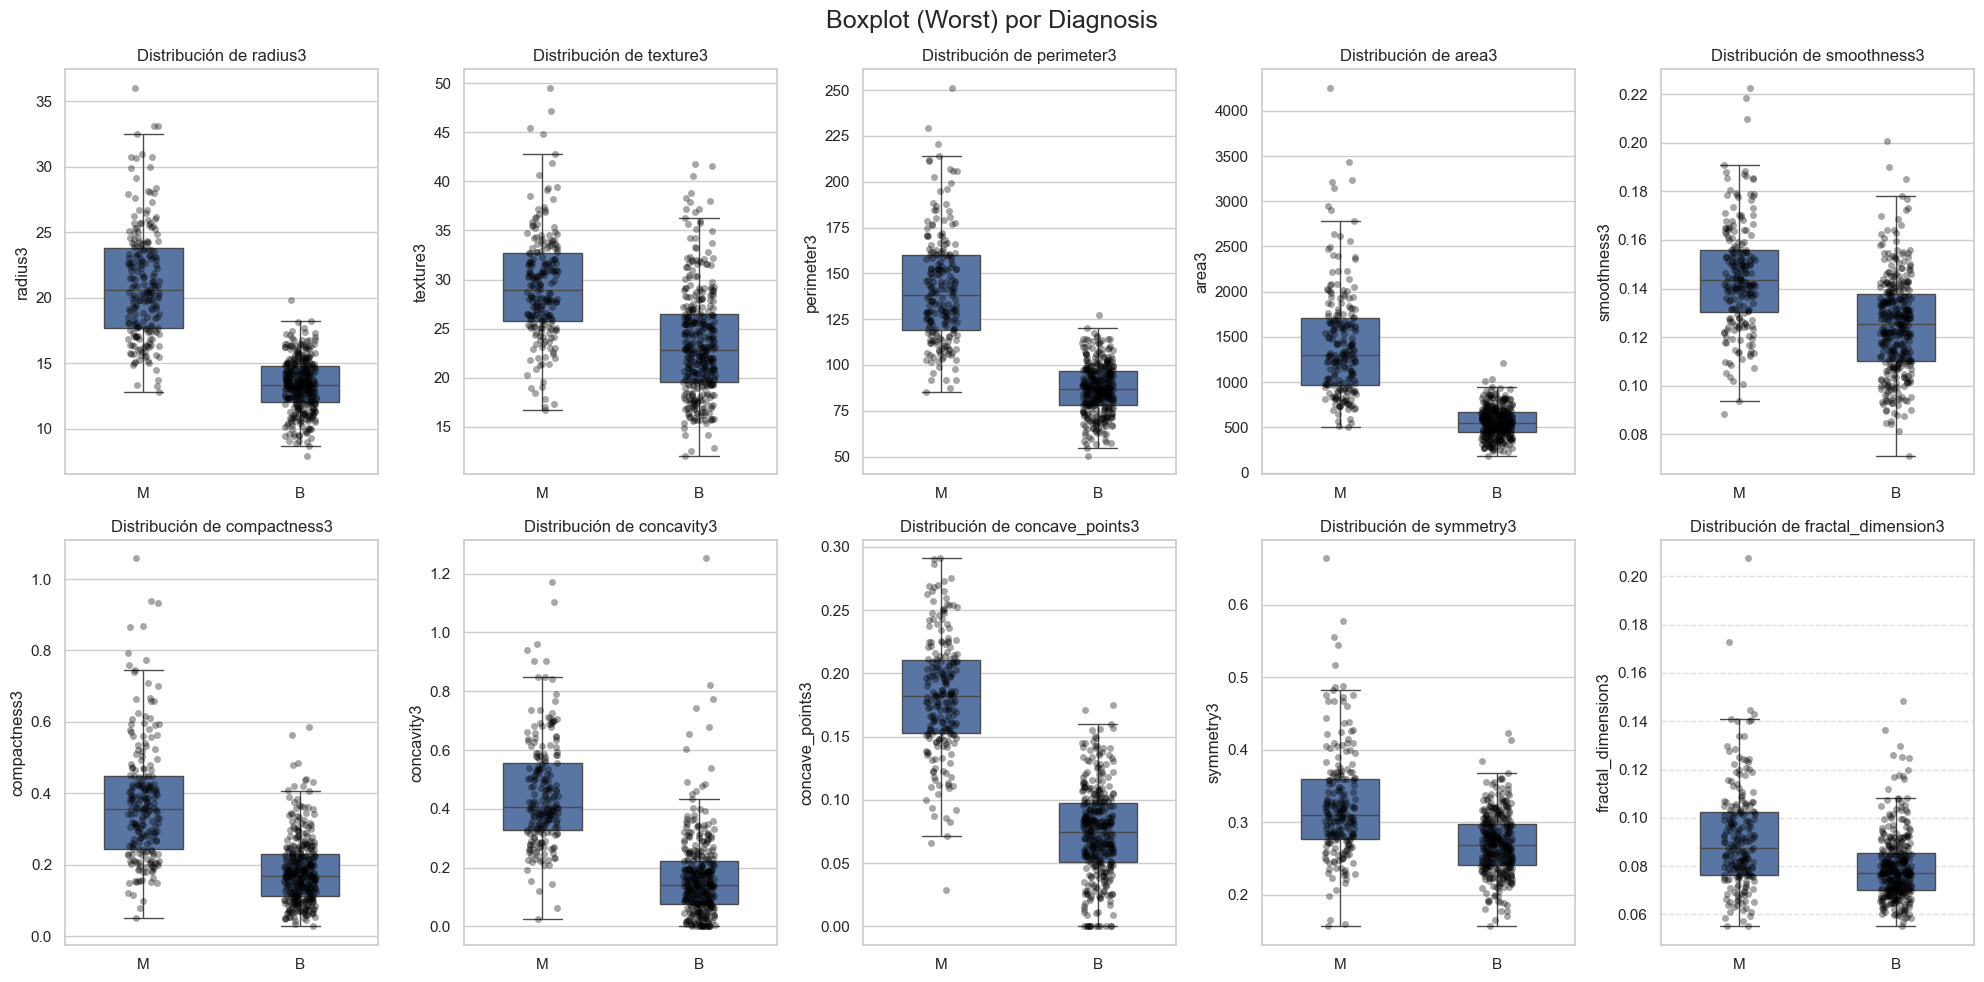

In [106]:
# Filtrar solo las columnas de medias (terminadas en 1) ignorando el ID
mean_features = [col for col in df.columns if col.endswith('3') and col != 'ID']

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(mean_features):
    sns.boxplot(x='Diagnosis', y=col, data=df, ax=axes[i], width=0.5, fliersize=0)
    sns.stripplot(x="Diagnosis", y=col, data=df, ax=axes[i], color="black", alpha=0.35, jitter=True)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('')

fig.suptitle("Boxplot (Worst) por Diagnosis", fontsize=18)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

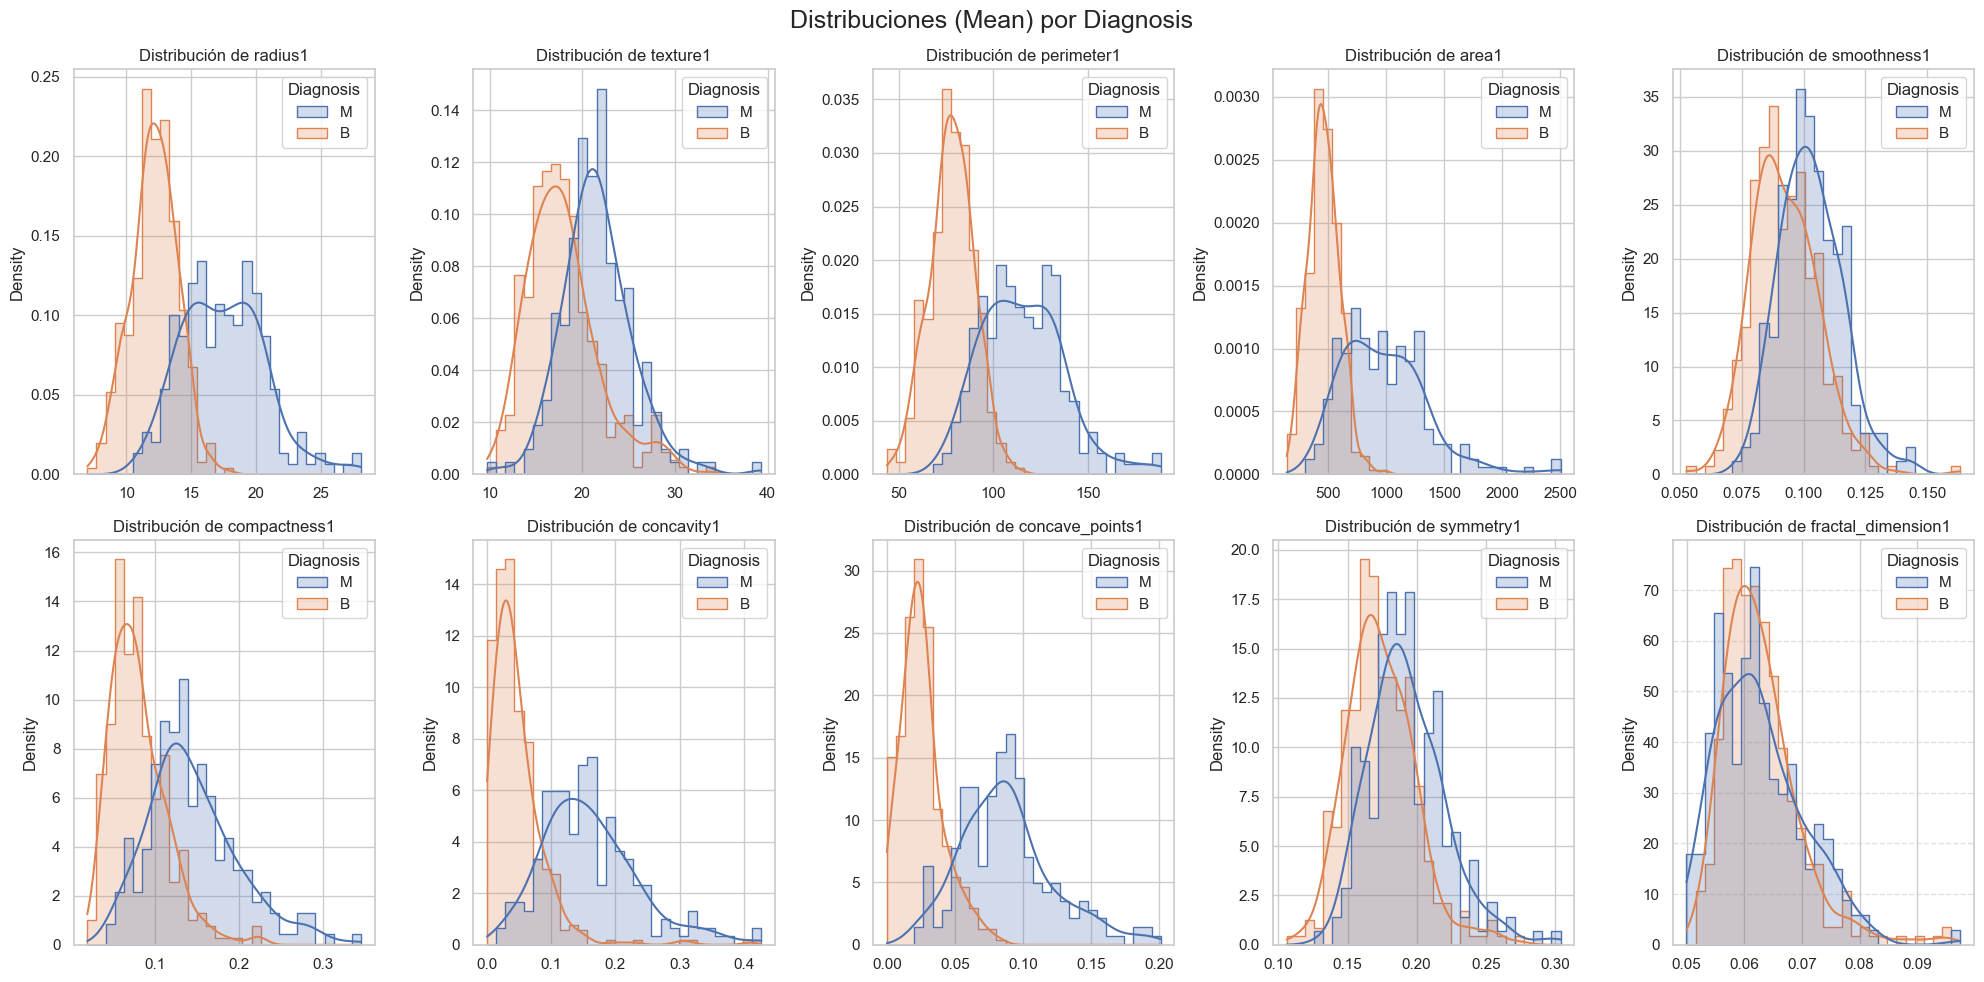

In [105]:
# Filtrar solo las columnas de medias (terminadas en 1) ignorando el ID
mean_features = [col for col in df.columns if col.endswith('1') and col != 'ID']

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(mean_features):
    sns.histplot(df, x=col, hue="Diagnosis", ax=axes[i], bins=30, kde=True,
             element="step", stat="density", common_norm=False)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('')

fig.suptitle("Distribuciones (Mean) por Diagnosis", fontsize=18)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

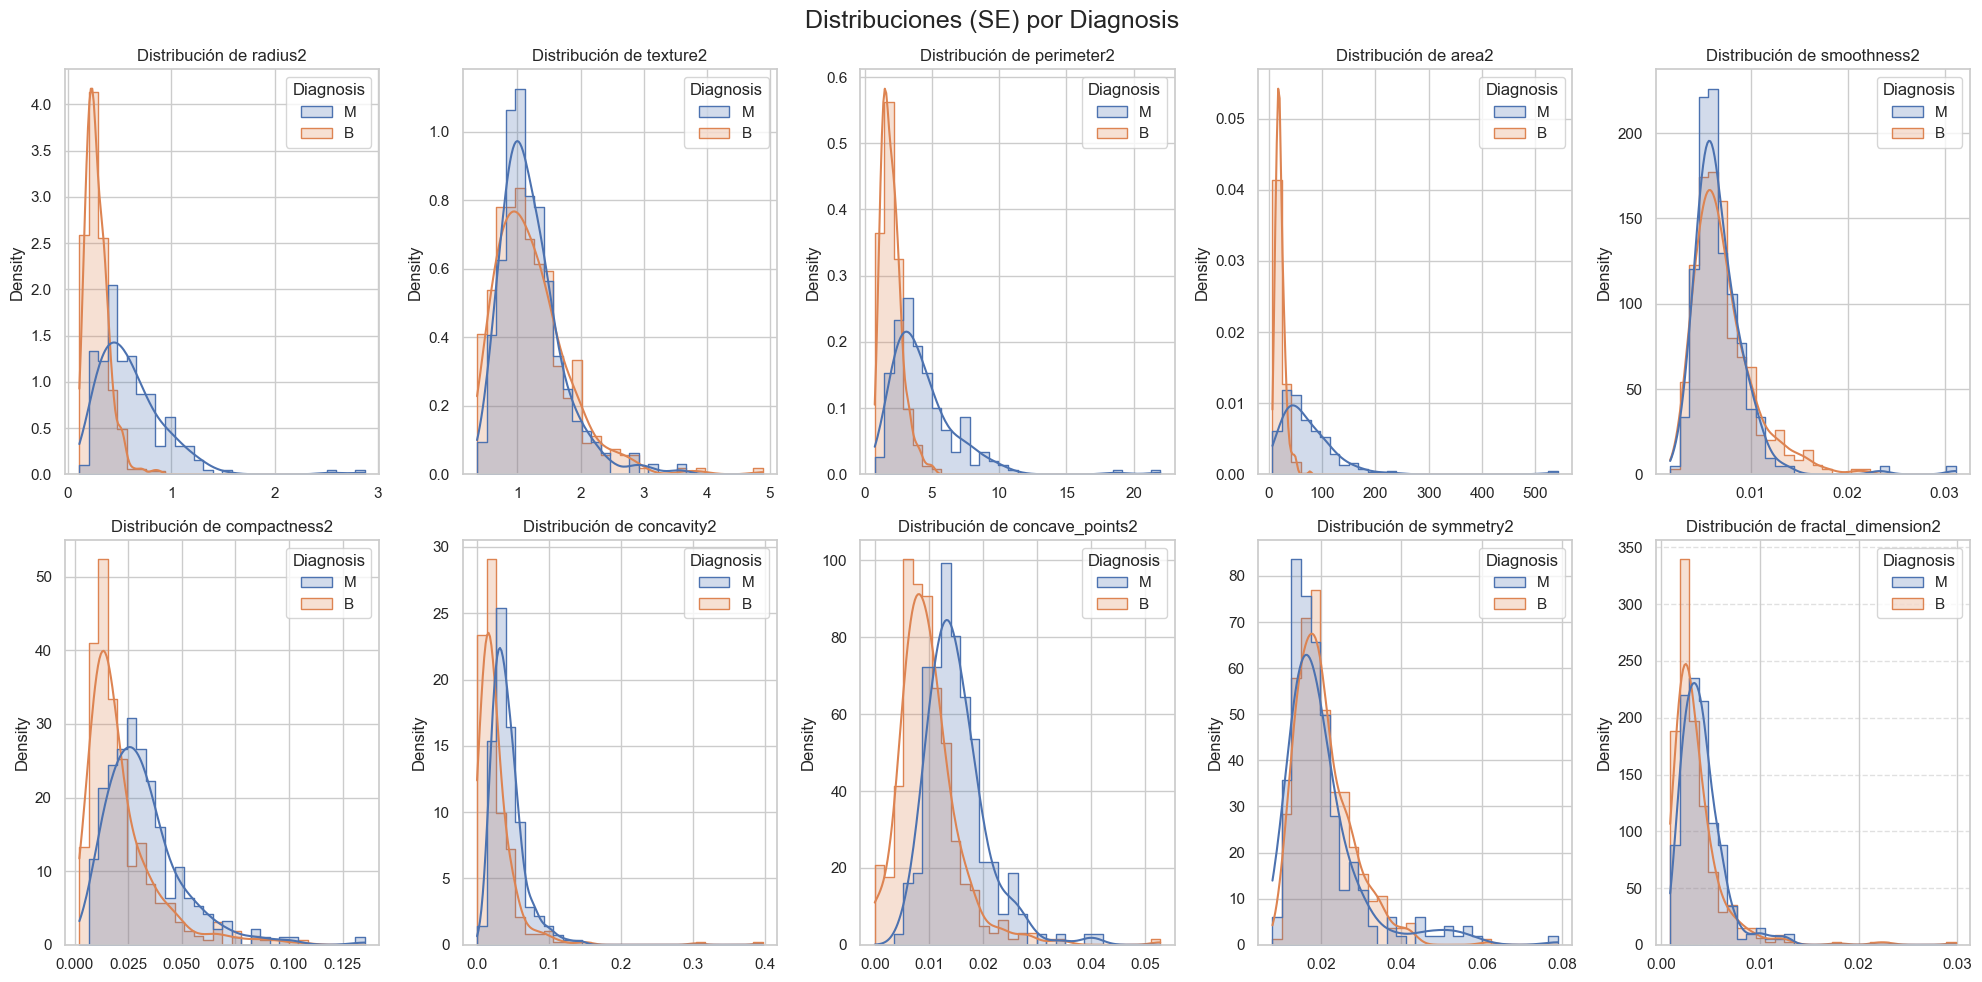

In [104]:
# Filtrar solo las columnas de medias (terminadas en 1) ignorando el ID
mean_features = [col for col in df.columns if col.endswith('2') and col != 'ID']

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(mean_features):
    sns.histplot(df, x=col, hue="Diagnosis", ax=axes[i], bins=30, kde=True,
             element="step", stat="density", common_norm=False)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('')

fig.suptitle("Distribuciones (SE) por Diagnosis", fontsize=18)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

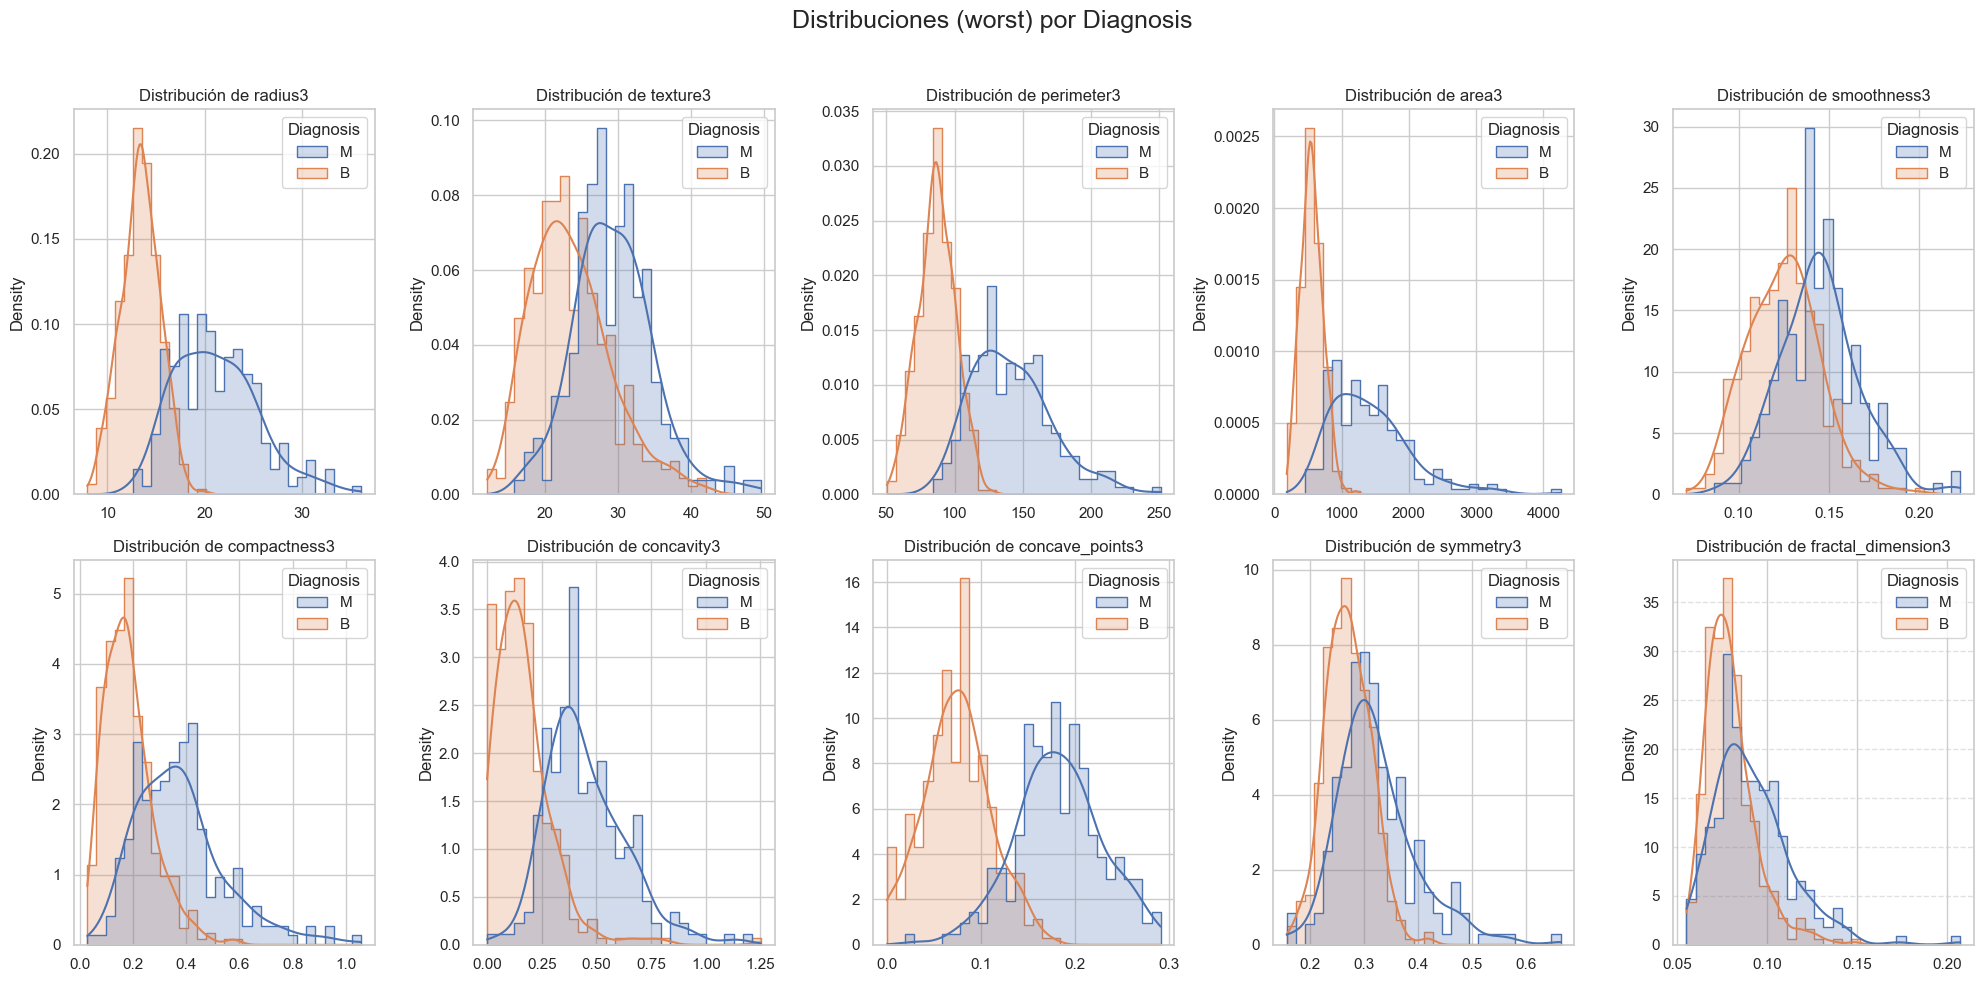

In [103]:
mean_features = [col for col in df.columns if col.endswith('3') and col != 'ID']

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(mean_features):
    sns.histplot(df, x=col, hue="Diagnosis", ax=axes[i], bins=30, kde=True,
             element="step", stat="density", common_norm=False)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('')

fig.suptitle("Distribuciones (worst) por Diagnosis", fontsize=18)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


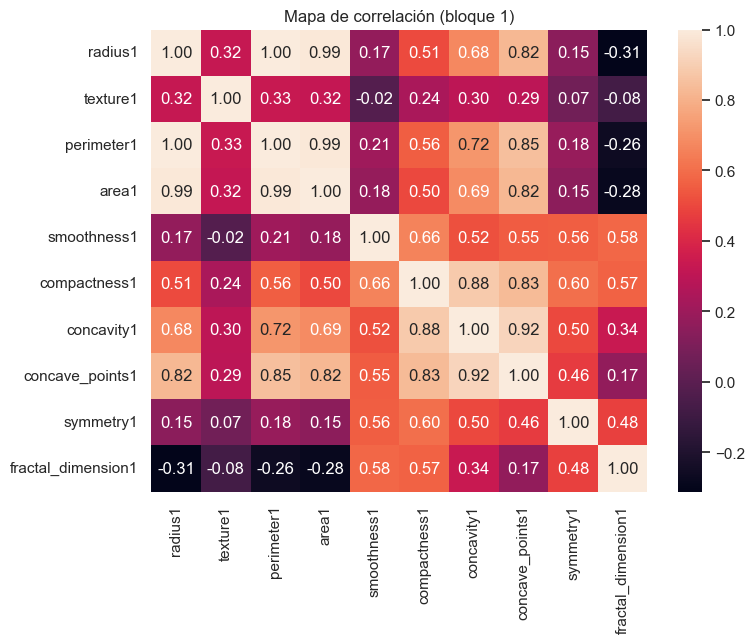

In [60]:
corr = df[variables_media].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Mapa de correlación (bloque 1)")
plt.show()

## 5. Interpretaciones Iniciales

¿Qué tendencias o patrones básicos se observan?

- La variable Diagnosis nos muestra dos grupos, Benigno y Maligno en donde se puede evidenciar que para estos pacientes hubo una mayor proporción de benignidad.
- En los histogramas podemos ver que  variables como radius1, perimeter1 y area1 están asociados a valores más altos para malignidad, lo que puede sugerir una relación entre el tamaño del núcleo y la malignidad, a mayor tamaño hay más factibilidad de tener este diagnóstico.
- Respecto a las variables de forma como concavity1 y concave_points 1 podemos ver como valores más altos suelen estar asociados con malignidad, es decir que núcleos más iregulares se asocian con este diagnóstico.
- Por su parte en los scatter pudimos visibilizar una relación positiva fuerte entre radius1, perimeter1 y area1 lo cual tiene todo el sentido si consideramos que el perímetro y el área son variables dependientes del radio, por lo que si este crece estas variables también van a aumentar.
- En el scatter de concavity1 vs concave_points1 pudimos observar agrupaciones en donde los casos malignos tendían a concentrarse en valores altos de ambas variables mientras que los benignos aparecían en valores mas bajos, esto puede sugerir cierta capacidad de discriminación entre clases.


¿Qué limitaciones tiene la base de datos?
- Algunas variables están fuertemente correlacionadas tal como podemos ver en el análisis de correlaciones y esto puede generar redundancia.
- Hay desbalance entre las clases, hay más casos benignos que malignos y esto podría generar afectaciones en el modelo si no se controla de forma adecuada.
- Se debe tener en cuenta que los datos son resúmenes de imágenes, no la imagen completa, lo que quiere decir que se está perdiendo información espacial y visual.
- En algunas de las variables los valores extremos pueden influir en las tendencias y en los histogramas.


¿Qué hipótesis iniciales podrían plantearse para análisis posteriores?
- Los tumores malignos presentan valores mayores en las variables ligadas a tamaño como radius1, perimeter1, area1.
- Los tumores malignos presentan mayores valores en variables asociadas a irregularidad como lo son concavity1 y concavepoints1.
- Podríamos reducir las variables muy correlaciones mediante selección de variables o PCA.
- Combinar variables de tamaño con aquellas de irregularidad podría mejorar la separación entre Malignidad y Benignidad en comparación con utilizar solo un tipo de variable.

## 6. Conclusiones

Las visualizaciones exploratorias nos muestras que el diagnóstico de Benignidad o Malignidad se relaciona con diversas características numéricas del tumor, en particular con aquellas asociadas al tamaño como el perímetro y el área, y a la irregularidad de la forma como la concavidad y los puntos cóncavos, pues estos tienden a tomar valores más altos en casos malignos, lo cual sugiere una separación visual que puede ser útil a la hora de formular modelos de clasificación.

Este análisis preliminar aporta una base para formular hipótesis y para posteriormente llevar a cabo etapas como la selección de variables, validación estadística y construcción de modelos de clasificación.


## 7. Referencias

Wolberg, W., Mangasarian, O., Street, N., & Street, W. (1993). Breast Cancer Wisconsin (Diagnostic) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DW2B.

[Breast Cancer Diagnosis and Prognosis via Linear Programming](https://aaai.org/papers/0019-ss94-01-019-breast-cancer-diagnosis-and-prognosis-via-linear-programming/)